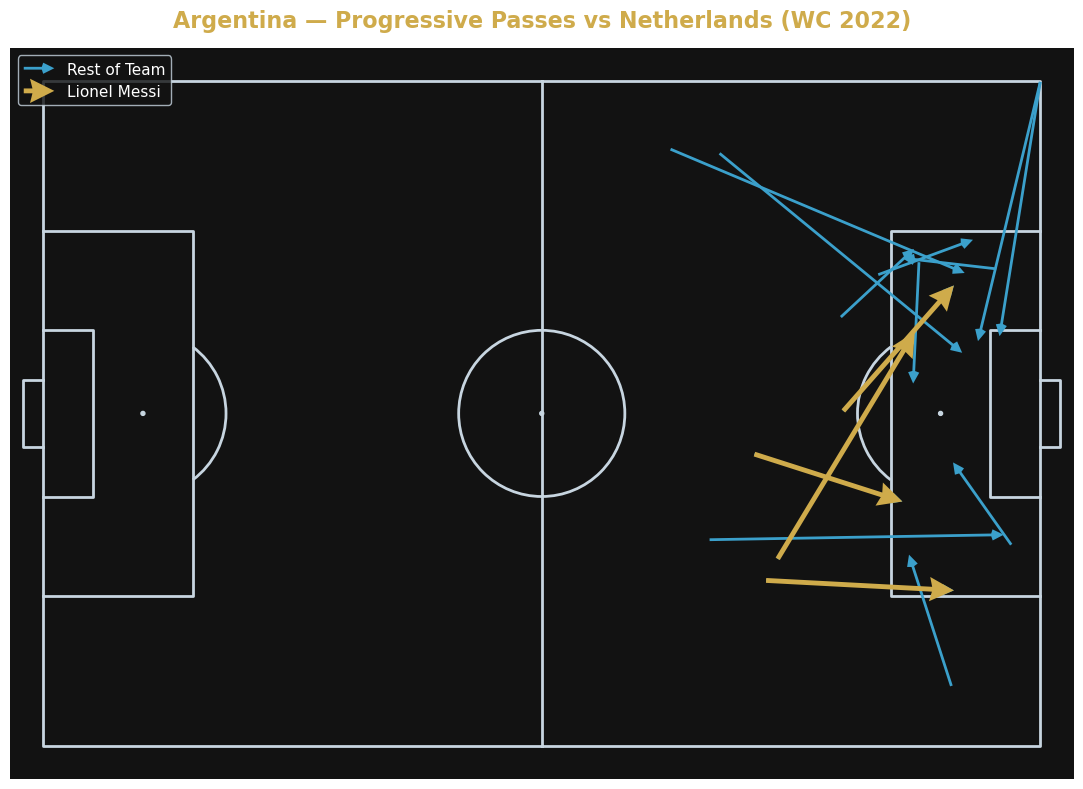

In [16]:
from statsbombpy import sb
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',None)
# Argentina vs Netherlands 2022 World Cup match_id: 3869321
events = sb.events(match_id=3869321)
events

# Filter completed passes
passes = events[(events["type"] == "Pass") & (events["pass_outcome"].isna())].copy()
passes

# Extract start and end coordinates
passes[["x","y"]] = passes["location"].tolist() 
passes[["end_x","end_y"]] = passes["pass_end_location"].apply(lambda loc :loc [:2]).tolist()
passes

passes[["player","pass_recipient","x","y","end_x","end_y"]].head()

# Calculate starting and ending distance to center of opponent's goal (120, 40)
passes["dist_start"] = np.sqrt((120-passes["x"]) ** 2 + (40-passes["y"])**2)
passes["dist_end"] = np.sqrt((120-passes["end_x"]) ** 2 + (40-passes["end_y"])**2)

# Check if pass enters penalty box( x >= 102, y between 18 and 62)
passes["in_box"] =  (passes["end_x"] >= 102) & (passes["end_y"].between(18,62))

# Applying Progressive Pass rules
# 1 Exclude defensive 40% of pitch (x >= 48)
# 2 Advance ball at least 10 yards closer to goal OR enter penalty box
prog_passes = passes[(passes["x"] >= 48) & (((passes["dist_start"] - passes["dist_end"]) >=10) | (passes["in_box"]))].copy()

arg_prog_passes = prog_passes[(prog_passes["team"] == "Argentina") & (prog_passes["in_box"] == True)].copy()
selected_col_arg = ["location","minute","second","pass_end_location","pass_height","pass_length","player","pass_recipient","play_pattern","position","timestamp","x","y","end_x","end_y","dist_start","dist_end"]
arg_prog_passes = arg_prog_passes[selected_col_arg]

# CSV
arg_prog_passes.to_csv(r"D:\Pitch\argentina_progressive_passes.csv", index = False)

ned_prog_passes = prog_passes[(prog_passes["team"] == "Netherlands") & (prog_passes["in_box"] == True)].copy()
selected_col_ned = ["location","minute","second","pass_end_location","pass_height","pass_length","player","pass_recipient","play_pattern","position","timestamp","x","y","end_x","end_y","dist_start","dist_end"]
ned_prog_passes = ned_prog_passes[selected_col_ned]
#CSV
ned_prog_passes.to_csv(r"D:\Pitch\netherlands_progressive_passes.csv", index = False)



import matplotlib.pyplot as plt
from mplsoccer import Pitch

# Set up a dark-themed StatsBomb pitch
pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#121212",
    line_color="#c7d5e0",
    goal_type="box",
)
fig, ax = pitch.draw(figsize=(12, 8))

# Plot progressive pass vectors with arrows
pitch.arrows(
    arg_prog_passes["x"],
    arg_prog_passes["y"],
    arg_prog_passes["end_x"],
    arg_prog_passes["end_y"],
    color="#3BA0CB",  # Argentina Sky Blue
    width=2,
    headwidth=4,
    headlength=4,
    ax=ax,
    label="Rest of Team",
)

# Title and branding for your portfolio
plt.title(
    "Argentina — Progressive Passes vs Netherlands (WC 2022)",
    color="#CFAB4B",
    fontsize=16,
    pad=15,
    loc="center",
    fontweight="bold",
)
arg_prog_passes = arg_prog_passes[
    arg_prog_passes["play_pattern"] != "From Corner"
].copy()
messi_passes = arg_prog_passes[
    arg_prog_passes["player"].str.contains("Messi", na=False)
]
other_passes = arg_prog_passes[
    ~arg_prog_passes["player"].str.contains("Messi", na=False)
]
pitch.arrows(
    messi_passes["x"],
    messi_passes["y"],
    messi_passes["end_x"],
    messi_passes["end_y"],
    color="#CFAB4B",  # Bright Gold
    alpha=1.0,  # Fully opaque
    width=3.5,  # Thicker lines for emphasis
    headwidth=5,
    headlength=5,
    ax=ax,
    label="Lionel Messi",
)

ax.legend(
    facecolor="#121212",  # Matches pitch background color
    edgecolor="#c7d5e0",  # Light border matching pitch lines
    labelcolor="white",  # White text for readability
    loc="upper left",  # Places legend in empty top-left quadrant
    fontsize=11,
    framealpha=0.8,
)

plt.savefig(
    r"D:\Pitch\argentina_progressive_passes.png",
    dpi=400,
    bbox_inches="tight",
    facecolor="#121212",
)
plt.show()

In [17]:
# Top progressive passers
top_passers = (
    arg_prog_passes["player"]
    .value_counts()
    .reset_index(name="progressive_passes")
)

# Top progressive pass receivers (who was targeted?)
top_receivers = (
    arg_prog_passes["pass_recipient"]
    .value_counts()
    .reset_index(name="progressive_receptions")
)

print("Top Passers:\n", top_passers.head(5))
print("\nTop Receivers:\n", top_receivers.head(5))

Top Passers:
                            player  progressive_passes
0  Lionel Andrés Messi Cuccittini                   4
1             Alexis Mac Allister                   3
2                  Enzo Fernandez                   2
3             Marcos Javier Acuña                   1
4                  Julián Álvarez                   1

Top Receivers:
                  pass_recipient  progressive_receptions
0       Lautaro Javier Martínez                       3
1          Nahuel Molina Lucero                       2
2           Alexis Mac Allister                       2
3  Nicolás Alejandro Tagliafico                       2
4           Marcos Javier Acuña                       1


In [20]:
pd.set_option('display.expand_frame_repr', False)

# Filter passes in the first half leading to high-threat zones
key_pass = arg_prog_passes[
    (arg_prog_passes["player"].str.contains("Messi", na=False))
    & (arg_prog_passes["minute"] >= 2)
]
print(key_pass[["minute", "second", "player","pass_recipient", "location", "pass_end_location"]])

      minute  second                          player                pass_recipient      location pass_end_location
74         4      29  Lionel Andrés Messi Cuccittini          Nahuel Molina Lucero  [87.0, 60.1]     [109.6, 61.3]
149        9      56  Lionel Andrés Messi Cuccittini           Marcos Javier Acuña  [96.3, 39.7]     [109.6, 24.6]
450       34       2  Lionel Andrés Messi Cuccittini          Nahuel Molina Lucero  [85.6, 44.9]     [103.4, 50.6]
1090      93      32  Lionel Andrés Messi Cuccittini  Nicolás Alejandro Tagliafico  [88.4, 57.5]     [104.9, 30.2]
